### Working Handwriting Network for Gabriel
In short: the problem wasn't your network, the problem was the conversion of the image.

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_datasets as tfds
import cv2
from keras.layers import Input,Dense,Flatten
from keras.models import Sequential
from keras.datasets import mnist

In [254]:
(trainx, trainy), (testx, testy) = mnist.load_data()

These are what the images in the dataset look like:

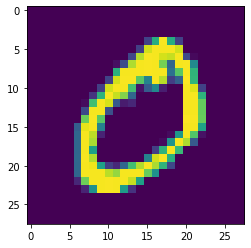

In [257]:
plt.imshow(trainx[1])

These are from the matrices that look like this. Notice there's a bunch of zeroes (corresponding to light) then lots of large values 100+ (corresponding to dark).

In [256]:
trainx[1]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  51, 159, 253, 159,  50,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  48, 238, 252, 252, 252, 237,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In contrast, if we just greyscale our images, we end up with values that are super close together in the 128-200 range. So that when we resize the image, it blurs the boundary.

In [421]:
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

In [424]:
np.array(img)

array([[128, 128, 128, ..., 132, 132, 132],
       [128, 128, 128, ..., 132, 132, 132],
       [128, 128, 128, ..., 133, 133, 132],
       ...,
       [119, 119, 119, ..., 126, 124, 123],
       [119, 119, 119, ..., 125, 124, 124],
       [119, 119, 119, ..., 124, 125, 128]], dtype=uint8)

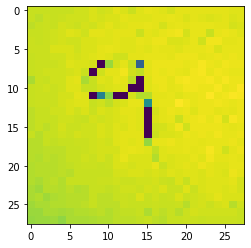

In [423]:
plt.imshow(cv2.resize(img,(28,28)))

Instead use the following:

In [460]:
# a ton of nonsense that was recommended to make the images output nicely (centers the number and adds a boundary)

def makepretty(image_path, threshold):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    thresh, newimg = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY_INV)
    contours, thresh = cv2.findContours(newimg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    digit_crop = newimg[y : y + h, x : x + w]
    max_dim = max(w, h)
    scale_ratio = 20 / max_dim
    new_w = int(w * scale_ratio)
    new_h = int(h * scale_ratio)
    digit_resized = cv2.resize(digit_crop, (new_w, new_h), interpolation=cv2.INTER_AREA)
    mnistimg = np.zeros(target_size)
    start_x = (target_size[1] - new_w) // 2
    start_y = (target_size[0] - new_h) // 2
    mnistimg[start_y : start_y + new_h, start_x : start_x + new_w] = digit_resized
    return mnistimg

Now the boundary is respected

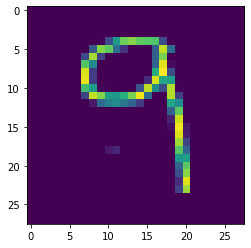

In [318]:
mnistimg = makepretty(r"C:\Users\Garrett\Downloads\thenumber9.png", 100)
plt.imshow(mnistimg)

This looks fine. So, now we train a model.

In [491]:
model = Sequential(
    [Input((28,28)), 
        Flatten(),
        Dense(256, activation="relu"),
        Dense(256, activation="relu"),        
        Dense(256, activation="relu"),
        Dense(64, activation="relu"),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(16, activation="relu"),
        Dense(10, activation="softmax")]
)

In [492]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [493]:
model.summary()

Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_11 (Flatten)        (None, 784)               0         
                                                                 
 dense_60 (Dense)            (None, 256)               200960    
                                                                 
 dense_61 (Dense)            (None, 256)               65792     
                                                                 
 dense_62 (Dense)            (None, 256)               65792     
                                                                 
 dense_63 (Dense)            (None, 64)                16448     
                                                                 
 dense_64 (Dense)            (None, 64)                4160      
                                                                 
 dense_65 (Dense)            (None, 32)              

In [494]:
model.fit(x=trainx, y=trainy, epochs=6, validation_split=0.2)

Epoch 1/6
1500/1500 [==============================] - 15s 9ms/step - loss: 0.4632 - accuracy: 0.8730 - val_loss: 0.2130 - val_accuracy: 0.9431
Epoch 2/6
1500/1500 [==============================] - 14s 9ms/step - loss: 0.1907 - accuracy: 0.9488 - val_loss: 0.1761 - val_accuracy: 0.9497
Epoch 3/6
1500/1500 [==============================] - 14s 9ms/step - loss: 0.1493 - accuracy: 0.9601 - val_loss: 0.1839 - val_accuracy: 0.9521
Epoch 4/6
1500/1500 [==============================] - 14s 9ms/step - loss: 0.1253 - accuracy: 0.9668 - val_loss: 0.1708 - val_accuracy: 0.9554
Epoch 5/6
1500/1500 [==============================] - 14s 10ms/step - loss: 0.1076 - accuracy: 0.9715 - val_loss: 0.1446 - val_accuracy: 0.9615
Epoch 6/6
1500/1500 [==============================] - 14s 10ms/step - loss: 0.0949 - accuracy: 0.9751 - val_loss: 0.1206 - val_accuracy: 0.9710


### Test on my 3 photo

1/1 [==============================] - 0s 31ms/step
Predicted Digit: 3
Confidence: 100.00%


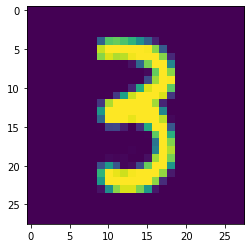

In [509]:
mnistimg = makepretty(r"C:\Users\Garrett\Downloads\thenumber3.png", 100)
predictions = model.predict(np.reshape(mnistimg, (1,28,28)))
predicted_digit = np.argmax(predictions)
confidence = np.max(predictions) * 100
print(f"Predicted Digit: {predicted_digit}")
print(f"Confidence: {confidence:.2f}%")
plt.imshow(mnistimg)

## Test on a MNIST 9 photo

1/1 [==============================] - 0s 40ms/step
Predicted Digit: 9
Confidence: 99.99%


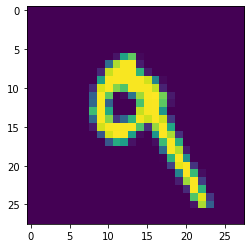

In [516]:
mnistimg = testx[7]
predictions = model.predict(np.reshape(mnistimg, (1,28,28)))
predicted_digit = np.argmax(predictions)
confidence = np.max(predictions) * 100
print(f"Predicted Digit: {predicted_digit}")
print(f"Confidence: {confidence:.2f}%")
plt.imshow(mnistimg)

## Test on my 9 photo (I think the ink was too thin and so it's less confident)

1/1 [==============================] - 0s 28ms/step
Predicted Digit: 9
Confidence: 23.96%


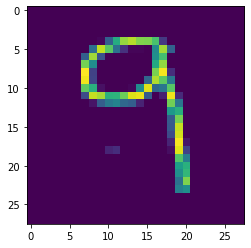

In [508]:
mnistimg = makepretty(r"C:\Users\Garrett\Downloads\thenumber9.png", 116)
predictions = model.predict(np.reshape(mnistimg, (1,28,28)))
predicted_digit = np.argmax(predictions)
confidence = np.max(predictions) * 100
print(f"Predicted Digit: {predicted_digit}")
print(f"Confidence: {confidence:.2f}%")
plt.imshow(mnistimg)